In [19]:
from pathlib import Path

"""
Replace with your desired directories
"""

from utility import repo_root

FIG_DIR = Path("/Users/zach/2025_RA/matthias/final images/2_wake_vs_sleep")
FIG_DIR.mkdir(parents=True, exist_ok=True)
BIDS_DIR = Path("/Users/zach/2025_RA/matthias/bids_sleepmreye")
CONFIG_DIR = Path(repo_root() / "sleepmreye" / "designs")

In [20]:
""" Load data """

from mreyemove.analysis.glm.cli import construct_desc
from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root=BIDS_DIR,
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean",
    load_EOG=False,
)

config = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)
desc_add = f"{desc_add}-{config.second_level.method}"
print(desc_add)

EOG data not full for 16, 1 (0/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (0/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (0/427). Skipping


clean-original-sleep-flame


# Figure A - Searchlight Correlation

In [3]:
"""
Building neighbourhoods takes a while - just do it once
"""

from mreyemove.analysis.searchlight_correlation import build_fsaverage_neighborhoods
radius_mm = 38  # geodesic radius in mm
surf_mesh = "fsaverage7"

neighborhoods = build_fsaverage_neighborhoods(surf_mesh=surf_mesh, radius_mm=radius_mm)

[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Building geodesic neighborhoods (radius=38mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 2230, Median: 2164, Min: 799, Max: 4393
Building geodesic neighborhoods (radius=38mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 2272, Median: 2208, Min: 865, Max: 4762


In [12]:
"""
Wake vs Sleep Cerebrum Searchlight
"""

from SleepMReye.plotting import plot_surface_searchlight
from mreyemove.analysis.searchlight_correlation import run_fsaverage_surface_searchlight_correlation



comparisons = [
    ("mreyemove_W", "mreyemove_S"),
]
corr_maps = {}

for contrast_a, contrast_b in comparisons:
    print(f"\n=== {contrast_a} vs {contrast_b} ===")

    data_a, _ = mrio.load_FLAME_result(contrast=contrast_a, desc_add=desc_add)
    data_b, _ = mrio.load_FLAME_result(contrast=contrast_b, desc_add=desc_add)

    print(data_a.t_stat.shape)

    corr_map, _ = run_fsaverage_surface_searchlight_correlation(
        data_b.t_stat, data_a.t_stat,
        surf_mesh=surf_mesh,
        neighborhoods=neighborhoods
    )
    corr_maps[f"{contrast_a}_{contrast_b}"] = corr_map

    plot_surface_searchlight(
        corr_map,
        surf_mesh=surf_mesh,
        inflate=True,
        title=f"Searchlight r: {contrast_a} vs {contrast_b} ({radius_mm}mm geodesic)",
        output_file=FIG_DIR / f"{contrast_a}_{contrast_b}_{radius_mm}mm_correlation_map.png"
    )


=== mreyemove_W vs mreyemove_S ===
(53, 65, 43)
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 67.1%
r_valid <= -0.3: 2.4%
n valid vertices = 163828
r_valid >=  0.3: 67.1%
r_valid <= -0.3: 2.4%
median r: 0.4740239381790161
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 61.4%
r_valid <= -0.3: 4.7%
n valid vertices = 163842
r_valid >=  0.3: 61.4%
r_valid <= -0.3: 4.7%
median r: 0.43407610058784485
median r: 0.45413345098495483
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


In [15]:
"""
Building neighbourhoods takes a while - just do it once
"""
import os
from SUITPy import flatmap
from mreyemove.analysis.searchlight_correlation import build_neighbourhoods


radius_mm = 29.0
surf_path = os.path.join(flatmap._base_dir,'surfaces', f'PIAL_FSL.surf.gii')
neighbourhoods = build_neighbourhoods(surf_mesh=surf_path, radius_mm=radius_mm)


Building geodesic neighborhoods (radius=29.0mm)...


Dijkstra neighborhoods:   0%|          | 0/58 [00:00<?, ?it/s]

Neighbors — Mean: 827, Median: 845, Min: 1, Max: 1336



=== mreyemove_W vs mreyemove_S ===

=== Cerbellum mreyemove_mreyemove_W vs mreyemove_mreyemove_S ===
n vertices = 28935
r_valid >=  0.3: 79.1%
r_valid <= -0.3: 2.7%
n valid vertices = 28834
r_valid >=  0.3: 79.3%
r_valid <= -0.3: 2.7%
median r: 0.599983274936676


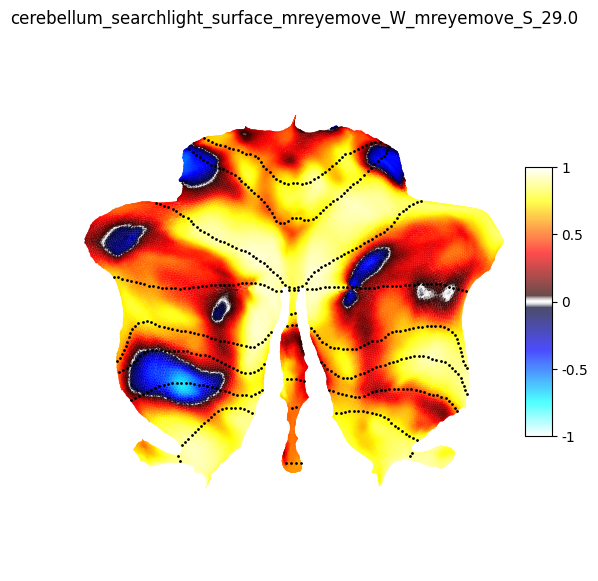

In [18]:
from mreyemove.plotting.glm import custom_cmap

"""
Wake vs Sleep Cerebellum Searchlight
"""

from SUITPy import flatmap
from mreyemove.analysis.searchlight_correlation import surface_searchlight_correlation

config = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep_cer.yml")
desc_add = construct_desc(dataset=mrio, config=config)
desc_add = f"{desc_add}-{config.second_level.method}"


comparisons = [
    ("mreyemove_W", "mreyemove_S"),
]

for contrast_a, contrast_b in comparisons:
    print(f"\n=== Cerebellum mreyemove_{contrast_a} vs mreyemove_{contrast_b} ===")
    title = f"cerebellum_searchlight_surface_{contrast_a}_{contrast_b}_{radius_mm}"
    
    vol_a,_ = mrio.load_FLAME_result(contrast=contrast_a, desc_add=desc_add)
    vol_b,_ = mrio.load_FLAME_result(contrast=contrast_b, desc_add=desc_add)
    
    surf_a = flatmap.vol_to_surf(vol_a.t_stat, space='FSL')
    surf_b = flatmap.vol_to_surf(vol_b.t_stat, space='FSL')
    
    results = surface_searchlight_correlation(
        map_a_surf=surf_a,
        map_b_surf=surf_b,
        neighborhoods=neighbourhoods,
        min_vertices=10,
    )
    
    corr_maps[f"cerebellum_{contrast_a}_{contrast_b}"] = results
    
    ax = flatmap.plot(data=results, cmap=custom_cmap(), 
            new_figure=True, 
            colorbar=True, 
            render='matplotlib',
            cscale=[-1.0, 1.0])
    ax.set_title(title)

    output_path = FIG_DIR / f"{title}.png"

    ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")
